In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
import geopandas as gpd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import ART_downscale as ART_down
from function import ART_statistic as ART_stat

import warnings
warnings.filterwarnings('ignore')

In [2]:
product, time_reso = 'ENSEMBLE', '1dy'

# product, time_reso = 'IMERG', '1dy'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'CHIRPS', '1dy'

# product, time_reso = 'ERA5', '3h'

# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'GSMaP', '3h'

In [3]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy')
obs_base = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [4]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

In [5]:
if product == 'ENSEMBLE':
    dir_sat = os.path.join(dir_base, 'Satellite', '5_ENSEMBLE')
else:
    dir_sat = os.path.join(dir_base, 'Satellite', '5_DOWN')

data_dir = os.path.join(dir_sat, f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(data_dir)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)
years = DATA.year.values

In [6]:
METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy_CLEAR.csv'))
print(f'Number of Stations: {len(METADATA)}')

Number of Stations: 2919


In [7]:
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

lon_list, lat_list, elev_list = [], [], []
OBS_list, SAT_list, DOWN_list = [], [], []
RE_DOWN_list, RE_SAT_list = [], []
ME_DOWN_list, ME_SAT_list = [], []

for nn in range(len(METADATA)):

    name = METADATA['File'].values[nn]
    ISO = METADATA['ISO'].values[nn]
    lat_obs = METADATA['Lat'].values[nn]
    lon_obs = METADATA['Lon'].values[nn]
    elev_obs = METADATA['DEM_Elevation'].values[nn]

    dir_station = os.path.join(dir_base,'Rain_Gauges_QC','Weibull','1dy',ISO,name)
    DF_OBS = pd.read_csv(dir_station)
    DF_OBS = DF_OBS.drop(columns='NaN')

    PREC_DOWN = DATA.sel(lat=lat_obs, lon=lon_obs, method='nearest')

    DF_SAT = pd.DataFrame({
                            'Year':PREC_DOWN.year.values, 
                            'Ns':PREC_DOWN.NYs.values, 'Cs':PREC_DOWN.CYs.values, 'Ws':PREC_DOWN.WYs.values,
                            'Nd':PREC_DOWN.NYd.values, 'Cd':PREC_DOWN.CYd.values, 'Wd':PREC_DOWN.WYd.values})

    merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

    merged_df_clean = merged_df.dropna(subset=['N'])
    
    if merged_df_clean.Ns.values.sum() == 0 or np.isnan(merged_df_clean.Ns.values.sum()) == True:
        lon_list.append(np.nan)
        lat_list.append(np.nan)
        elev_list.append(np.nan)
        OBS_list.append(np.nan)
        SAT_list.append(np.nan)
        DOWN_list.append(np.nan)
        RE_SAT_list.append(np.nan)
        RE_DOWN_list.append(np.nan)
        ME_SAT_list.append(np.nan)
        ME_DOWN_list.append(np.nan)

    else:
        x0 = 9.0*np.nanmean(merged_df_clean.C.values)
        quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.N.values, merged_df_clean.C.values, merged_df_clean.W.values, thresh=1)
        QQ_OBS = np.where(flag, quant, np.nan)

        x0 = 9.0*np.nanmean(merged_df_clean.Cs.values)
        quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.Ns.values, merged_df_clean.Cs.values, merged_df_clean.Ws.values, thresh=1)
        QQ_SAT = np.where(flag, quant, np.nan)

        x0 = 9.0*np.nanmean(merged_df_clean.Cd.values)
        quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.Nd.values, merged_df_clean.Cd.values, merged_df_clean.Wd.values, thresh=1)
        QQ_DOWN = np.where(flag, quant, np.nan)

        RE_SAT = (QQ_SAT - QQ_OBS) / QQ_OBS
        RE_DOWN = (QQ_DOWN - QQ_OBS) / QQ_OBS
        
        ME_SAT = QQ_SAT/QQ_OBS
        ME_DOWN = QQ_DOWN/QQ_OBS

        lon_list.append(lon_obs)
        lat_list.append(lat_obs)
        elev_list.append(elev_obs)
        OBS_list.append(QQ_OBS[3])
        SAT_list.append(QQ_SAT[3])
        DOWN_list.append(QQ_DOWN[3])
        RE_SAT_list.append(RE_SAT[3])
        RE_DOWN_list.append(RE_DOWN[3])
        ME_SAT_list.append(ME_SAT[3])
        ME_DOWN_list.append(ME_DOWN[3])

elev_norm = (elev_list-np.nanmin(elev_list))/(np.nanmax(elev_list)-np.nanmin(elev_list))

PD_RE  = pd.DataFrame({'Lon':lon_list,'Lat':lat_list, 'Elev':elev_list, 'Elev_norm':elev_norm, 'Mevd_OBS':OBS_list, 'Mevd_SAT':SAT_list, 'Mevd_DOWN':DOWN_list, 'RE_SAT':RE_SAT_list, 'RE_DOWN':RE_DOWN_list, 'ME_SAT':ME_SAT_list, 'ME_DOWN':ME_DOWN_list})

dir_out = os.path.join('..','..','output','RE',f'RE_{product}.csv')
PD_RE.to_csv(dir_out, header=True, index=None)

In [8]:
PD_RE.head(3)

,Lon,Lat,Elev,Elev_norm,Mevd_OBS,Mevd_SAT,Mevd_DOWN,RE_SAT,RE_DOWN,ME_SAT,ME_DOWN
0,7.847798,45.514302,338.677490,0.111968,189.421186,101.070345,115.816194,-0.466425,-0.388578,0.533575,0.611422
1,7.390821,44.963696,322.049591,0.106513,163.298540,98.279786,100.264705,-0.398159,-0.386004,0.601841,0.613996
2,7.492737,45.288798,582.489075,0.191947,258.766315,104.728681,129.658481,-0.595277,-0.498936,0.404723,0.501064


In [9]:
scatter_cmap = 'coolwarm_r'

RE_levels = np.arange(-1,1.1,0.1)
RE_norm = mcolors.BoundaryNorm(boundaries=RE_levels, ncolors=256)
RE_ticks = np.arange(-1,1.2,0.2)

ME_levels = np.arange(0,2.1,0.1)
ME_norm = mcolors.BoundaryNorm(boundaries=ME_levels, ncolors=256)
ME_ticks = np.arange(0,2.2,0.2)

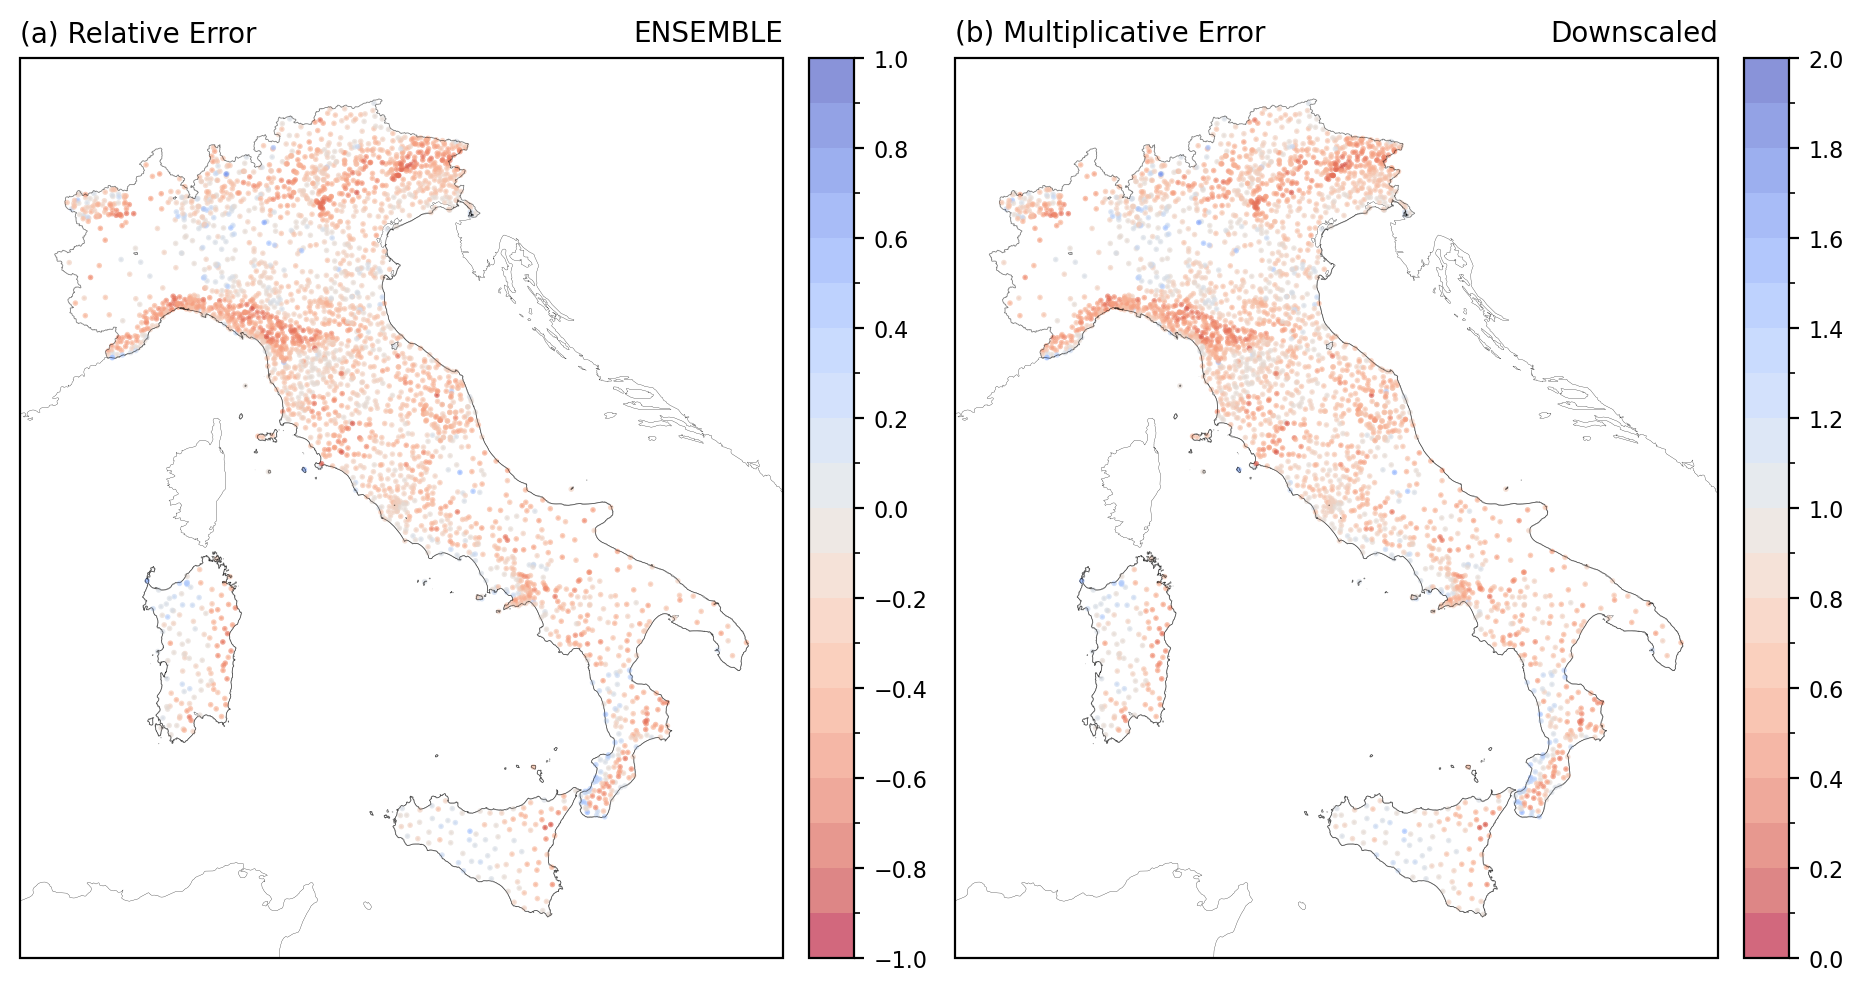

In [10]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10,5),dpi=200)
gs = gridspec.GridSpec(1,2)

# ======================================================================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)

a1 = ax1.scatter(
    PD_RE['Lon'],
    PD_RE['Lat'],
    c=PD_RE['RE_DOWN'],
    cmap=scatter_cmap,
    s=1,
    norm=RE_norm,
    alpha=0.6,
    zorder=20
    )

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03, ticks=RE_ticks)
cbar.ax.tick_params(labelsize=8)

ax1.set_title('(a) Relative Error',fontsize=10, loc='left')
ax1.set_title(product,fontsize=10, loc='right')

# ======================================================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)

a1 = ax1.scatter(
    PD_RE['Lon'],
    PD_RE['Lat'],
    c=PD_RE['ME_DOWN'],
    cmap=scatter_cmap,
    s=1,
    norm=ME_norm,
    alpha=0.6,
    zorder=20
    )

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03, ticks=ME_ticks)
cbar.ax.tick_params(labelsize=8)

ax1.set_title('(b) Multiplicative Error',fontsize=10, loc='left')
ax1.set_title('Downscaled',fontsize=10, loc='right')

# ======================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.08, hspace=0.13)

dir_out = os.path.join('..','..','figure','RE',f'DOWN_RE_ME_{product}.png')
# plt.savefig(dir_out,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)

In [11]:
PD_RE = PD_RE.sort_values('Elev_norm')

In [12]:
VAL_x, VAL_y, VAL_slope = ART_stat.linear_regression(PD_RE.Mevd_OBS, PD_RE.Mevd_DOWN)

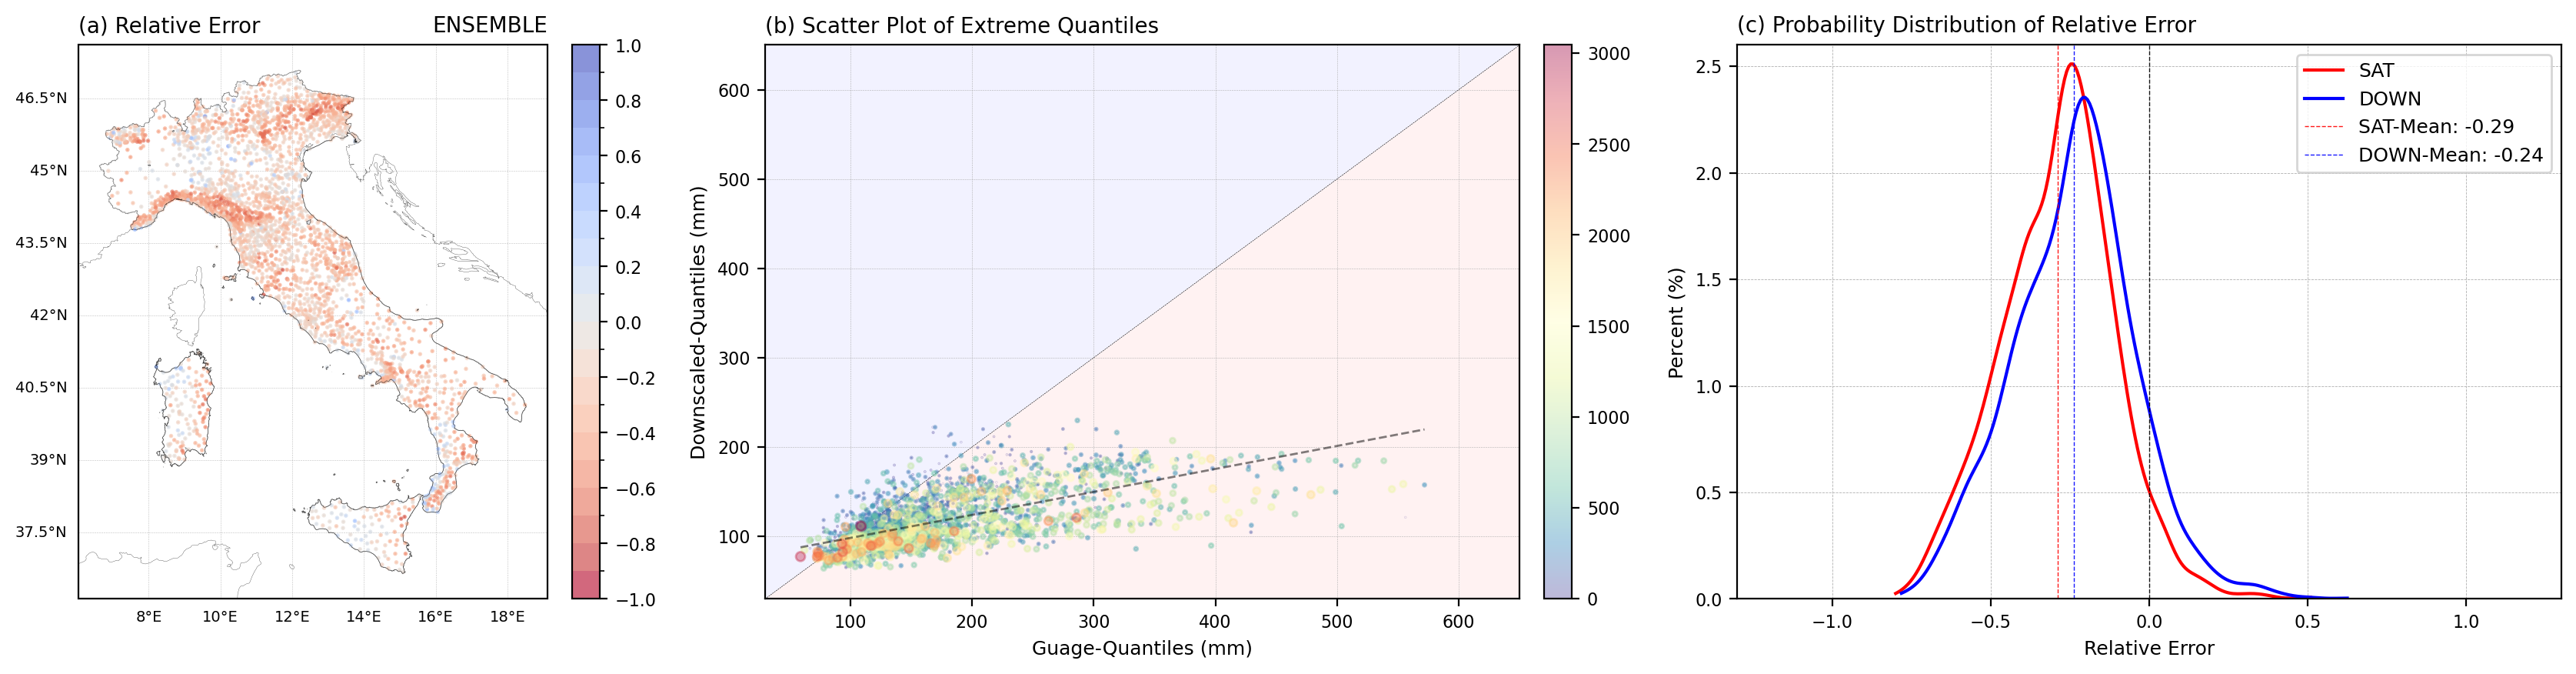

In [15]:
val_max = 600
vmin = PD_RE.Elev.min()
vmax = PD_RE.Elev.max()

fig = plt.figure(figsize=(20,4),dpi=200)
gs = gridspec.GridSpec(1,3)


# ======================================================================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)

a1 = ax1.scatter(
    PD_RE['Lon'],
    PD_RE['Lat'],
    c=PD_RE['RE_DOWN'],
    cmap=scatter_cmap,
    s=1,
    norm=RE_norm,
    alpha=0.6,
    zorder=20
    )

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = False
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03, ticks=RE_ticks)
cbar.ax.tick_params(labelsize=8)

ax1.set_title('(a) Relative Error',fontsize=10, loc='left')
ax1.set_title(product,fontsize=10, loc='right')

# ======================================================================================================================================================
ax1 = plt.subplot(gs[0, 1])
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(30,val_max+50)
ax1.set_ylim(30,val_max+50)
ax1.grid(linestyle='--', linewidth=0.2)
ax1.tick_params(axis='both', which='major', labelsize=8)

xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
x_vals = np.linspace(min(xlim[0], ylim[0]), max(xlim[1], ylim[1]), 200)
ax1.fill_between(x_vals, ylim[0], x_vals, facecolor="red", alpha=0.05, zorder=0)
ax1.fill_between(x_vals, x_vals, ylim[1], facecolor="blue", alpha=0.05, zorder=0)

ax1.plot(np.arange(val_max+50),np.arange(val_max+50),'--k', linewidth=0.2, label='Identity line')
ax1.scatter([],[], s=5, c='darkred', label='Ensemble Satellite')
ax1.scatter([],[], s=5, c='darkblue', label='Ensemble Downscaled')

a1 = ax1.scatter(
    PD_RE.Mevd_OBS, PD_RE.Mevd_DOWN,
    alpha=0.4,
    s=PD_RE.Elev_norm*20,
    c=PD_RE.Elev,
    vmin=vmin, vmax=vmax,
    zorder=10, cmap="Spectral_r")

ax1.plot(VAL_x, VAL_y, "--k", linewidth=1, label="Linear Fit", alpha=0.5,zorder=12)

ax1.set_title('(b) Scatter Plot of Extreme Quantiles',fontsize=10, loc='left')
ax1.set_xlabel('Guage-Quantiles (mm)',fontsize=9)
ax1.set_ylabel('Downscaled-Quantiles (mm)',fontsize=9)

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=8)

# ======================================================================================================================================================
ax1 = plt.subplot(gs[0, 2])
sns.kdeplot(PD_RE.RE_SAT,color='r', linestyle='-',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'SAT',
            clip=(np.nanmin(np.array(PD_RE.RE_SAT)), np.nanmax(np.array(PD_RE.RE_SAT))))
sns.kdeplot(PD_RE.RE_DOWN,color='b', linestyle='-',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'DOWN',
            clip=(np.nanmin(np.array(PD_RE.RE_DOWN)), np.nanmax(np.array(PD_RE.RE_DOWN))))

ax1.axvline(np.nanmean(PD_RE.RE_SAT), color='r',linestyle='--',linewidth=0.5,alpha=0.9, label=f'SAT-Mean: {np.round(np.nanmean(PD_RE.RE_SAT),2)}')
ax1.axvline(np.nanmean(PD_RE.RE_DOWN), color='b',linestyle='--',linewidth=0.5,alpha=0.9, label=f'DOWN-Mean: {np.round(np.nanmean(PD_RE.RE_DOWN),2)}')

ax1.axvline(0, color='k',linestyle='--',linewidth=0.5,alpha=0.9)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.3,1.3)
ax1.set_ylim(0,2.6)
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_ylabel('Percent (%)',fontsize=9)
ax1.set_xlabel('Relative Error',fontsize=9)
ax1.legend(fontsize=9, loc=0, ncol=1)

ax1.set_title('(c) Probability Distribution of Relative Error',fontsize=10, loc='left')

# ======================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.18, hspace=0.13)

dir_out = os.path.join('..','..','figure','RE',f'DOWN_ALL_{product}.png')
plt.savefig(dir_out,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)
